In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

I0000 00:00:1779272394.212855    4877 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779272394.595440    4877 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779272397.135847    4877 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
spect = np.load('spectrums.npy')
labels = pd.read_csv('FM_Parameter_Table.csv')
auxill = pd.read_csv('AuxillaryTable.csv')

wavelengths = spect[ 0, :, 0]
spectrum = spect[:, :, 1]

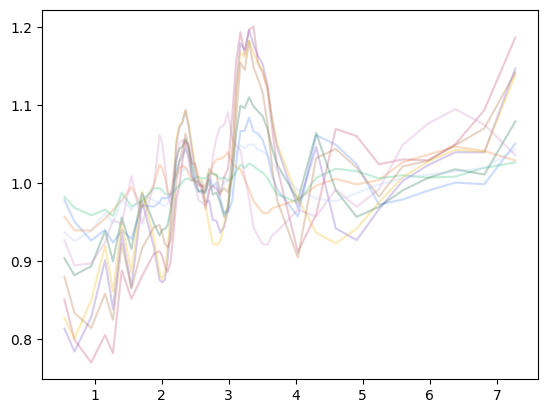

In [3]:
for i in np.random.choice(len(spectrum), 10):
  plt.plot(wavelengths, spectrum[i]/np.mean(spectrum[i]), alpha=0.3)

In [14]:
output = labels['log_H2O'].values

In [15]:
y_norm = normalize(output.reshape(1, -1), norm='l2').ravel()
X_norm = normalize(spectrum, norm='l2')

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, test_size=0.1, random_state=1)

In [23]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [26]:
model.compile(metrics=['mae'], optimizer='adam', loss='mse')

In [27]:
model.fit(X_train, y_train, epochs=10, shuffle=True, validation_split=0.3, batch_size=10)

Epoch 1/10
2610/2610 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 2.5436e-06 - mae: 0.0012 - val_loss: 1.7946e-06 - val_mae: 0.0010
Epoch 2/10
2610/2610 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 2.1981e-06 - mae: 0.0012 - val_loss: 4.5246e-06 - val_mae: 0.0019
Epoch 3/10
2610/2610 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 2.0828e-06 - mae: 0.0012 - val_loss: 2.9135e-06 - val_mae: 0.0015
Epoch 4/10
2610/2610 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 2.0262e-06 - mae: 0.0011 - val_loss: 1.0255e-06 - val_mae: 8.3713e-04
Epoch 5/10
2610/2610 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 1.8985e-06 - mae: 0.0011 - val_loss: 1.1566e-06 - val_mae: 8.9331e-04
Epoch 6/10
2610/2610 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 1.7405e-06 - mae: 0.0011 - val_loss: 1.1822e-06 - val_mae: 8.3976e-04
Epoch 7/10
2610/2610 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 1.6500e-06 - mae: 0.0010 - val_loss: 1.0926e-06 - val_mae: 8.6558e-04
Epoch 8/10
2610/2610 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 1.4606e-06 - mae: 9.6302e-

In [29]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)

130/130 - 0s - 2ms/step - loss: 1.2384e-06 - mae: 9.4046e-04
